In [7]:
#imports
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.graph_objects as go 
import plotly.io as pio 
import os
print(os.getcwd())


/Users/bapbap23/Desktop/Banking-Churn-Binary-Classification/notebooks


In [8]:
#create a dataframe 
df = pd.read_csv('../bank.csv') 
#display the first 5 rows of the dataframe 
df.head() 
#display the last 5 rows of the dataframe 
df.tail() 


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


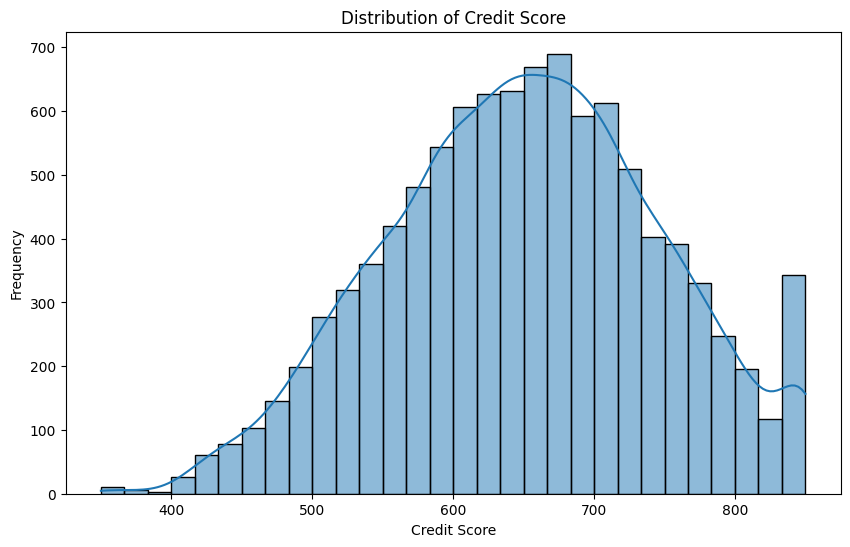

In [10]:
#check distribution of credit score
plt.figure(figsize=(10,6))
sns.histplot(df['CreditScore'], bins=30, kde=True)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()


In [ ]:
#create a new column for credit score category
df['CreditScoreCategory'] = pd.cut(df['CreditScore'], bins=[0, 500, 600, 700, 800, 900, 1000], labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent', 'Outstanding'])
#display the first 5 rows of the dataframe
df[['CreditScoreCategory', 'CreditScore', 'CustomerId', 'Surname']]



print(df['CreditScoreCategory'].value_counts())


CreditScoreCategory
Good           3818
Very Good      2471
Fair           2423
Excellent       645
Poor            643
Outstanding       0
Name: count, dtype: int64


In [20]:
category_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

df['CreditScoreCategory'] = pd.Categorical(
    df['CreditScoreCategory'],
    categories=category_order,
    ordered=True
)

df['CreditScoreCategory'].value_counts()

CreditScoreCategory
Good         3818
Very Good    2471
Fair         2423
Excellent     645
Poor          643
Name: count, dtype: int64

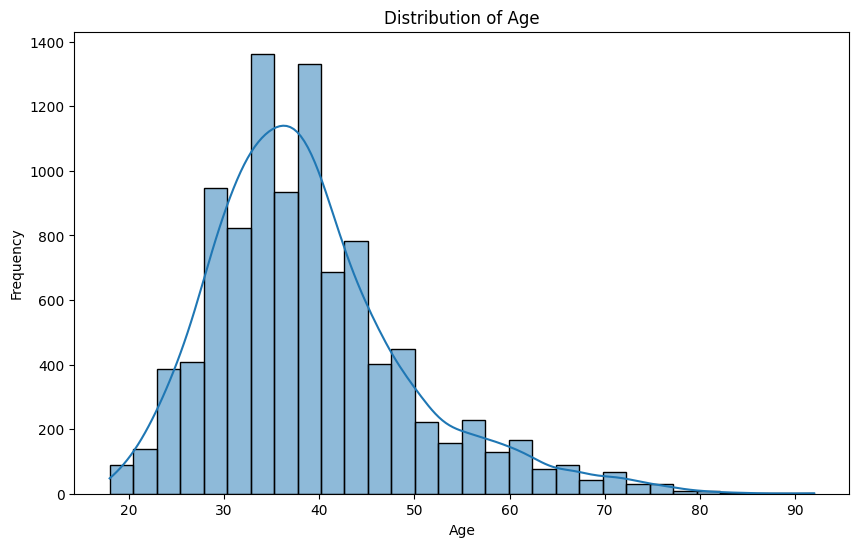

In [22]:
#age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()




In [26]:
#age category

df['AgeCategory'] = pd.cut(df['Age'], bins=[0, 34, 50, 100], labels=['young', 'middle age', 'old'])

df[['Surname', 'Age', 'AgeCategory']]

df['AgeCategory'].value_counts()

AgeCategory
middle age    5060
young         3679
old           1261
Name: count, dtype: int64

In [27]:
#quick check
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScoreCategory,AgeCategory
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Good,middle age
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Good,middle age
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Fair,middle age
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Good,middle age
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Excellent,middle age


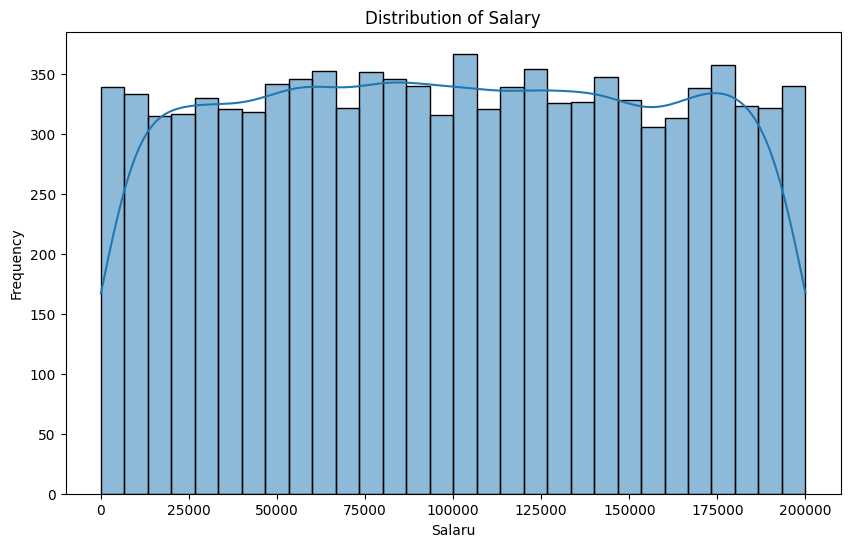

In [ ]:
#distribution of salary range

plt.figure(figsize=(10,6))
sns.histplot(df['EstimatedSalary'], bins=30, kde=True)
plt.title('Distribution of Salary')
plt.xlabel('Salaru')
plt.ylabel('Frequency')
plt.show()


In [33]:
df['SalaryRange'] = pd.cut(
    df['EstimatedSalary'],
    bins=[0, 50000, 100000, 150000, 200000],
    labels=['low', 'mid', 'high', 'very high'],
    include_lowest=True
)

df['SalaryRange'].value_counts()

SalaryRange
high         2555
mid          2537
very high    2455
low          2453
Name: count, dtype: int64

In [38]:
df.groupby(['Geography', 'IsActiveMember']).size().reset_index(name='count')


,Geography,IsActiveMember,count
0,France,0,2423
1,France,1,2591
2,Germany,0,1261
3,Germany,1,1248
4,Spain,0,1165
5,Spain,1,1312


In [40]:
df.groupby(['Geography','SalaryRange']).size().reset_index(name='count')

,Geography,SalaryRange,count
0,France,low,1222
1,France,mid,1297
2,France,high,1268
3,France,very high,1227
4,Germany,low,616
5,Germany,mid,616
6,Germany,high,640
7,Germany,very high,637
8,Spain,low,615
9,Spain,mid,624


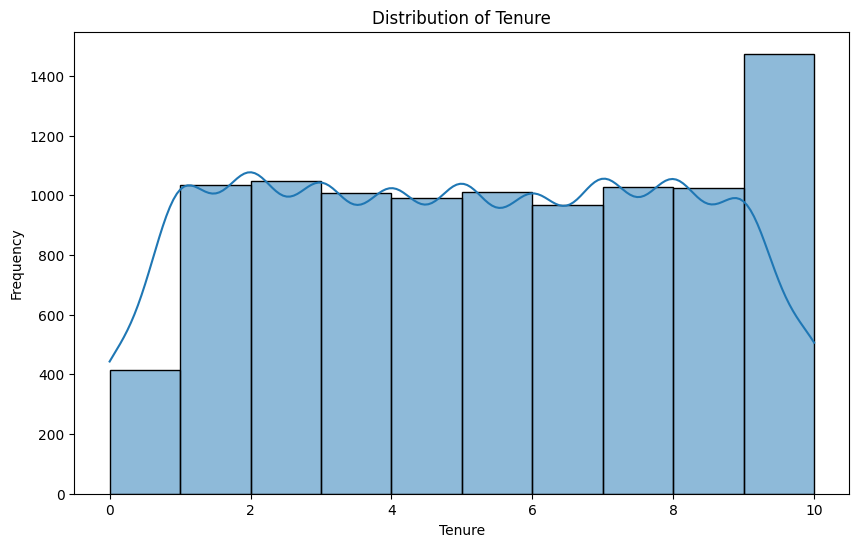

In [42]:
#distribution of tenure

plt.figure(figsize=(10,6))
sns.histplot(df['Tenure'], bins=10, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['TenureCategory'] = pd.cut(
    df['Tenure'],
    bins=[-1, 2, 7, 10],
    labels=['New', 'Established', 'Loyal']
)

df['TenureCategory'].value_counts()


TenureCategory
Established    5005
Loyal          2499
New            2496
Name: count, dtype: int64